<a href="https://colab.research.google.com/github/maikol0629/dl_voice_command_cl/blob/main/04%20-%20arquitectura%20crnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo CRNN: CNN 1D + BiLSTM para Clasificación de Comandos de Voz

In [1]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os
    try:
        from google.colab import userdata
        os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
        os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
    except Exception:
        pass

    !pip install -q kagglehub torch torchaudio pandas numpy matplotlib scikit-learn librosa soundfile audioread numba
    import kagglehub
    import shutil

    try:
        data_path = kagglehub.competition_download("voice-commands-classification-2026")
    except Exception as e:
        print("Error al descargar de Kaggle. Asegúrate de configurar KAGGLE_USERNAME y KAGGLE_KEY en tus Colab Secrets.")
        raise e

    if not os.path.exists('data'):
        os.symlink(data_path, 'data')

    if not os.path.exists('dl_voice_command_cl'):
        !git clone https://github.com/maikol0629/dl_voice_command_cl.git

    for f in ['train_metadata.csv', 'test_metadata.csv']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')
    for f in ['models.py', 'data.py']:
        src = os.path.join('dl_voice_command_cl', f)
        if os.path.exists(src) and not os.path.exists(f):
            shutil.copy(src, '.')

    DATA_PATH = os.path.join(data_path, 'train')
else:
    DATA_PATH = './data/train'


100%|██████████| 3.31G/3.31G [01:27<00:00, 40.8MB/s]

Extracting files...


Cloning into 'dl_voice_command_cl'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 91 (delta 49), reused 48 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 2.78 MiB | 10.95 MiB/s, done.
Resolving deltas: 100% (49/49), done.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchaudio.transforms as T

from models import AudioToMelSpectrogram, CRNNModel
from data import load_data
from sklearn.metrics import confusion_matrix, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cuda


In [10]:
# 3.98e-03              {'lstm_hidden': 128}
SAMPLE_RATE = 16000
BATCH_SIZE = 64
EPOCHS = 30
LR = 3.98e-03
N_CLASSES = 35
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256
N_CHANNEL = 32
PATIENCE = 5
VAL_SIZE = 0.2
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# VoiceCommandsDataset is now imported from data.py


In [5]:
AUDIO_DIR = os.path.join(DATA_PATH, 'train', 'train')

train_loader, val_loader, label_encoder, num_classes = load_data(
    train_metadata_csv='train_metadata.csv',
    train_audio_dir=AUDIO_DIR,
    val_size=VAL_SIZE, seed=SEED,
    batch_size=BATCH_SIZE,
)

print(f"Numero de clases: {num_classes}")
print("Clases:", list(label_encoder.classes_))
total = len(train_loader.dataset) + len(val_loader.dataset)
print(f"Total muestras: {total}")
print(f"Train: {len(train_loader.dataset)} | Val: {len(val_loader.dataset)}")

Numero de clases: 35
Clases: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']
Total muestras: 95246
Train: 76196 | Val: 19050


In [6]:
# Crear transformación a Mel-spectrogram
audio_transform = AudioToMelSpectrogram(
    sample_rate=SAMPLE_RATE, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
).to(device)


In [7]:
model = CRNNModel(num_classes=num_classes, lstm_hidden=128).to(device)
print(model)

# Verificar con un batch dummy
dummy = torch.randn(2, 1, N_MELS, 63).to(device)
out = model(dummy)
print(f"Salida shape: {out.shape}")

CRNNModel(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.2, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.2, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
    (14): Dropout2d(p=0.2, inplace=False)
  )
  (lstm): LS

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

In [11]:
best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for waveforms, labels in train_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)

        optimizer.zero_grad()
        outputs = model(mels)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item() * waveforms.size(0)
        preds = outputs.argmax(dim=1)
        train_total += labels.size(0)
        train_correct += (preds == labels).sum().item()

    epoch_train_loss = train_loss_sum / train_total
    epoch_train_acc = train_correct / train_total
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for waveforms, labels in val_loader:
            waveforms = waveforms.to(device)
            labels = labels.to(device)
            mels = audio_transform(waveforms)
            outputs = model(mels)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * waveforms.size(0)
            preds = outputs.argmax(dim=1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss_sum / val_total
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)

    scheduler.step(epoch_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc * 100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc * 100:.2f}%"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_crnn.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping en epoca {epoch + 1}")
            break

print("Entrenamiento completado.")

Epoch 01/30 | Train Loss: 0.4220 Acc: 87.19% | Val Loss: 0.3283 Acc: 90.09%
Epoch 02/30 | Train Loss: 0.3476 Acc: 89.45% | Val Loss: 0.2767 Acc: 91.57%
Epoch 03/30 | Train Loss: 0.3007 Acc: 90.87% | Val Loss: 0.2338 Acc: 93.10%
Epoch 04/30 | Train Loss: 0.2697 Acc: 91.69% | Val Loss: 0.2275 Acc: 93.12%
Epoch 05/30 | Train Loss: 0.2443 Acc: 92.44% | Val Loss: 0.2158 Acc: 93.47%
Epoch 06/30 | Train Loss: 0.2261 Acc: 93.00% | Val Loss: 0.1949 Acc: 94.18%
Epoch 07/30 | Train Loss: 0.2036 Acc: 93.74% | Val Loss: 0.2141 Acc: 93.59%
Epoch 08/30 | Train Loss: 0.1939 Acc: 93.96% | Val Loss: 0.2003 Acc: 94.16%
Epoch 09/30 | Train Loss: 0.1804 Acc: 94.41% | Val Loss: 0.1889 Acc: 94.45%
Epoch 10/30 | Train Loss: 0.1668 Acc: 94.71% | Val Loss: 0.1904 Acc: 94.54%
Epoch 11/30 | Train Loss: 0.1582 Acc: 95.02% | Val Loss: 0.1992 Acc: 94.28%
Epoch 12/30 | Train Loss: 0.1481 Acc: 95.33% | Val Loss: 0.1884 Acc: 94.64%
Epoch 13/30 | Train Loss: 0.1394 Acc: 95.63% | Val Loss: 0.1865 Acc: 94.59%
Epoch 14/30 

In [12]:
model.load_state_dict(torch.load('best_crnn.pth', map_location=device))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for waveforms, labels in val_loader:
        waveforms = waveforms.to(device)
        labels = labels.to(device)
        mels = audio_transform(waveforms)
        logits = model(mels)
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(labels.cpu().numpy().tolist())

val_acc = (np.array(y_true) == np.array(y_pred)).mean()
print(f"Accuracy en validacion: {val_acc * 100:.2f}%")

Accuracy en validacion: 95.12%


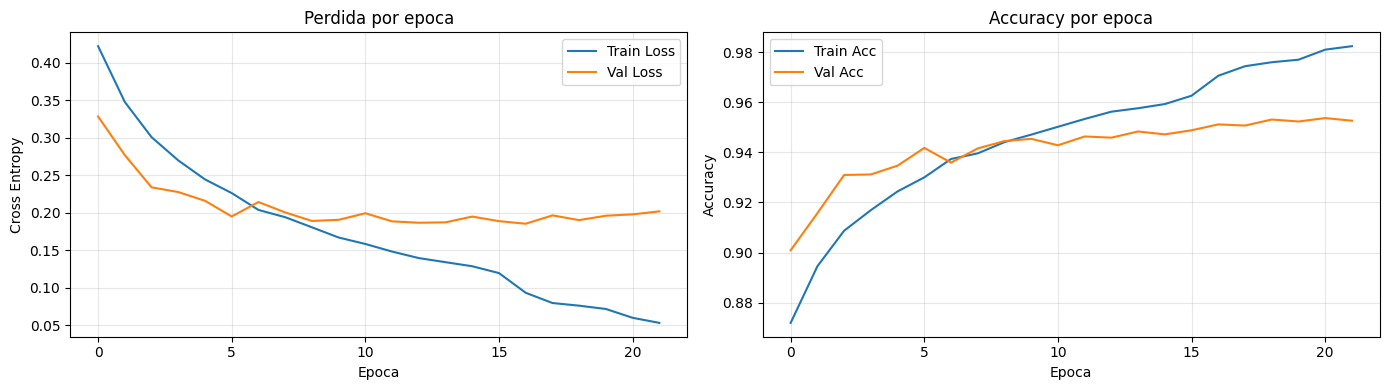

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses, label='Val Loss')
axes[0].set_title('Perdida por epoca')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Cross Entropy')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs, label='Val Acc')
axes[1].set_title('Accuracy por epoca')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

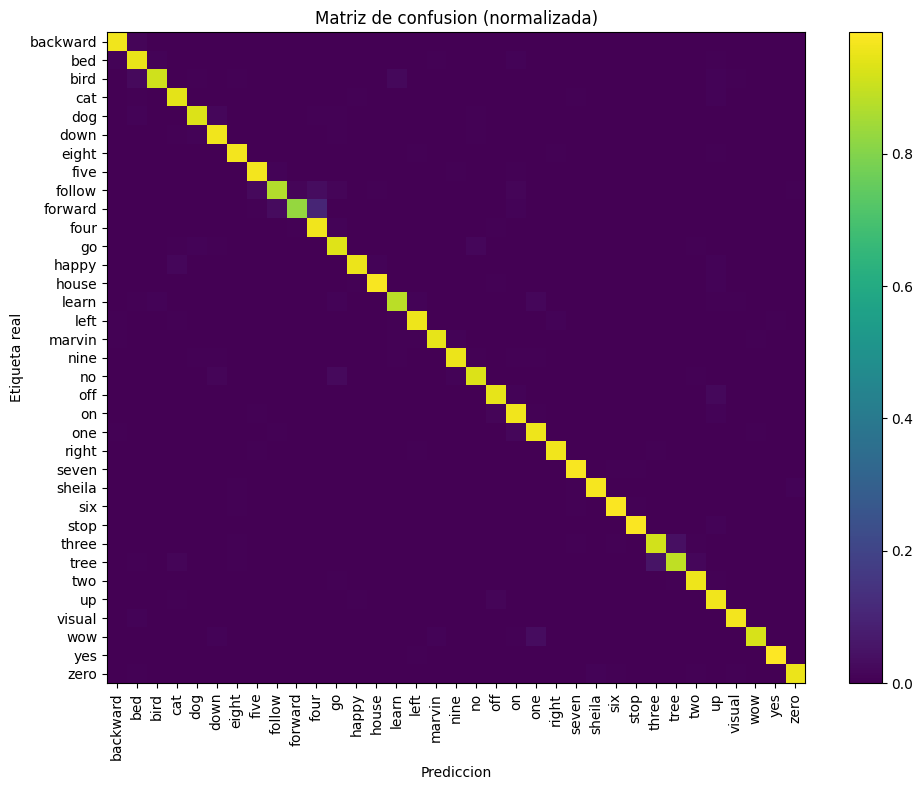

Reporte de clasificacion (validacion):
              precision    recall  f1-score   support

    backward       0.93      0.96      0.94       296
         bed       0.90      0.95      0.92       363
        bird       0.95      0.91      0.93       373
         cat       0.90      0.95      0.92       364
         dog       0.93      0.93      0.93       383
        down       0.95      0.96      0.96       702
       eight       0.97      0.96      0.97       683
        five       0.96      0.96      0.96       731
      follow       0.91      0.87      0.89       284
     forward       0.96      0.83      0.89       278
        four       0.92      0.96      0.94       674
          go       0.93      0.94      0.93       700
       happy       0.97      0.95      0.96       368
       house       0.97      0.97      0.97       381
       learn       0.91      0.88      0.90       281
        left       0.95      0.96      0.96       683
      marvin       0.98      0.95      0.9

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation='nearest', aspect='auto')
plt.title('Matriz de confusion (normalizada)')
plt.colorbar()

tick_marks = np.arange(len(label_encoder.classes_))
plt.xticks(tick_marks, label_encoder.classes_, rotation=90)
plt.yticks(tick_marks, label_encoder.classes_)
plt.xlabel('Prediccion')
plt.ylabel('Etiqueta real')
plt.tight_layout()
plt.show()

print('Reporte de clasificacion (validacion):')
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))

## Conclusiones

El entrenamiento del modelo CRNN ha mostrado resultados prometedores en la clasificación de comandos de voz. A continuación, se resumen los puntos clave:

- **Precisión en Validación**: El modelo alcanzó una precisión en validación del **95.12%**, lo cual indica una alta capacidad para clasificar correctamente los comandos de voz en el conjunto de datos de validación.
- **Pérdida y Precisión durante el Entrenamiento**: Las gráficas de pérdida y precisión por época (celda `SkR__eJQab9d`) demuestran que tanto la pérdida de entrenamiento como la de validación disminuyeron consistentemente, mientras que las precisiones aumentaron, lo que sugiere un proceso de aprendizaje efectivo y una buena generalización.
- **Early Stopping**: El entrenamiento se detuvo anticipadamente en la **época 22** (de 30 posibles) debido a que la pérdida en el conjunto de validación no mejoró. Esto es una buena práctica para evitar el sobreajuste y asegura que el modelo final no sea demasiado complejo para los datos de validación.
- **Análisis de la Matriz de Confusión y Reporte de Clasificación**: La matriz de confusión normalizada y el reporte de clasificación detallado (celda `HIlmY_Chab9e`) confirman que el modelo tiene un rendimiento robusto en la mayoría de las clases, con altos valores de precisión, recall y F1-score. Esto indica que el modelo es capaz de distinguir eficazmente entre los diferentes comandos de voz.